<a href="https://colab.research.google.com/github/ketannehra9/Data-Science-Guided-Projects/blob/main/GP_5_Obj_Loc_TF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
!mkdir emojis
!unzip -q openmoji-72x72-color.zip -d ./emojis
!pip install tensorflow==2.16.2

--2026-01-25 06:59:09--  https://github.com/hfg-gmuend/openmoji/releases/latest/download/openmoji-72x72-color.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip [following]
--2026-01-25 06:59:09--  https://github.com/hfg-gmuend/openmoji/releases/download/16.0.0/openmoji-72x72-color.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/114106318/9532d5d3-3294-49ab-b7f9-5da918081758?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-01-25T07%3A41%3A56Z&rscd=attachment%3B+filename%3Dopenmoji-72x72-color.zip&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-01-25T06%3A41%3A

In [1]:
!pip install --upgrade ml_dtypes


  Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.9 kB)
Using cached ml_dtypes-0.5.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.0 MB)
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.16.2 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.16.2 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.16.2 which is incompatible.
jax 0.7.2 requires numpy

In [2]:
%matplotlib inline

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from PIL import Image, ImageDraw
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D, BatchNormalization, Dropout

print('Check if we are using TensorFlow 2.4')
print('Using TensorFlow version', tf.__version__)

Check if we are using TensorFlow 2.4
Using TensorFlow version 2.16.2


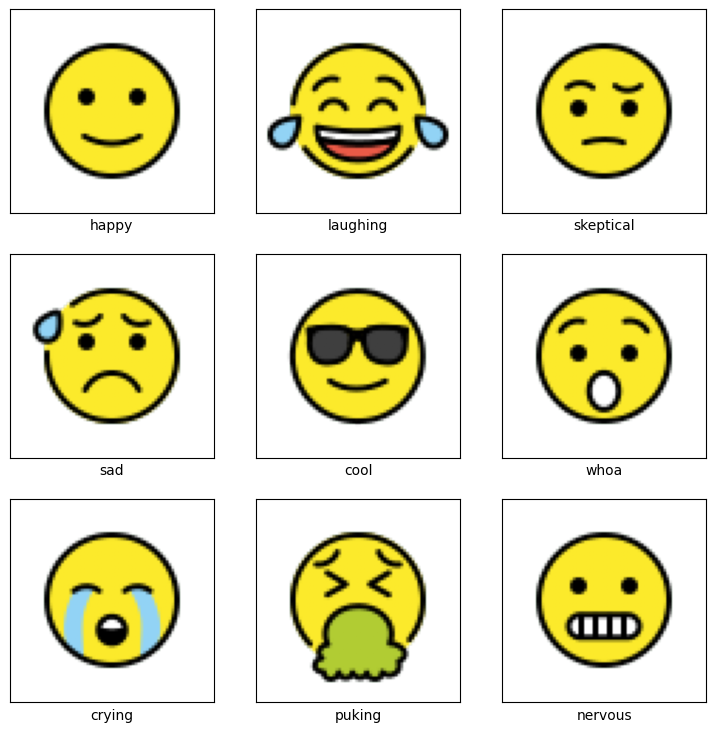

In [3]:
emojis = {
    0: {'name': 'happy', 'file': '1F642.png'},
    1: {'name': 'laughing', 'file': '1F602.png'},
    2: {'name': 'skeptical', 'file': '1F928.png'},
    3: {'name': 'sad', 'file': '1F630.png'},
    4: {'name': 'cool', 'file': '1F60E.png'},
    5: {'name': 'whoa', 'file': '1F62F.png'},
    6: {'name': 'crying', 'file': '1F62D.png'},
    7: {'name': 'puking', 'file': '1F92E.png'},
    8: {'name': 'nervous', 'file': '1F62C.png'}
}

plt.figure(figsize=(9, 9))

for i, (j, e) in enumerate(emojis.items()):
    plt.subplot(3, 3, i + 1)
    plt.imshow(plt.imread(os.path.join('emojis', e['file'])))
    plt.xlabel(e['name'])
    plt.xticks([])
    plt.yticks([])
plt.show()

In [4]:
for class_id, values in emojis.items():
    png_file = Image.open(os.path.join('emojis', values['file'])).convert('RGBA')
    png_file.load()
    new_file = Image.new("RGB", png_file.size, (255, 255, 255))
    new_file.paste(png_file, mask=png_file.split()[3])
    emojis[class_id]['image'] = new_file

In [5]:
emojis

{0: {'name': 'happy',
  'file': '1F642.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 1: {'name': 'laughing',
  'file': '1F602.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 2: {'name': 'skeptical',
  'file': '1F928.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 3: {'name': 'sad',
  'file': '1F630.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 4: {'name': 'cool',
  'file': '1F60E.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 5: {'name': 'whoa',
  'file': '1F62F.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 6: {'name': 'crying',
  'file': '1F62D.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 7: {'name': 'puking',
  'file': '1F92E.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>},
 8: {'name': 'nervous',
  'file': '1F62C.png',
  'image': <PIL.Image.Image image mode=RGB size=72x72>}}

In [6]:
def create_example():
  class_id = np.random.randint(0, 9)
  image = np.ones((144, 144, 3)) * 255

  row = np.random.randint(0, 72)
  col = np.random.randint(0, 72)

  image[row:row+72, col:col+72, :] = np.array(emojis[class_id]['image'])
  return image.astype('uint8'), class_id, (row + 10) / 144, (col + 10) / 144


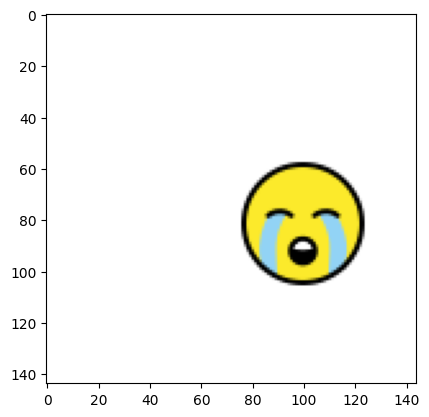

In [7]:
image, class_id, row, col = create_example()
plt.imshow(image)

In [8]:
def plot_bounding_box(image, gt_coords, pred_coords=[], norm=False):
  if norm:
    image *= 255
    image = image.astype('uint8')

  image = Image.fromarray(image)
  draw = ImageDraw.Draw(image)

  row, col = gt_coords
  row *= 144
  col *= 144
  draw.rectangle((col, row, col + 52, row+52), outline = 'green', width = 3)

  if len(pred_coords) == 2:
    row, col = pred_coords
    row *= 144
    col *= 144
    draw.rectangle((col, row, col + 52, row+52), outline = 'red', width = 3)


  return image





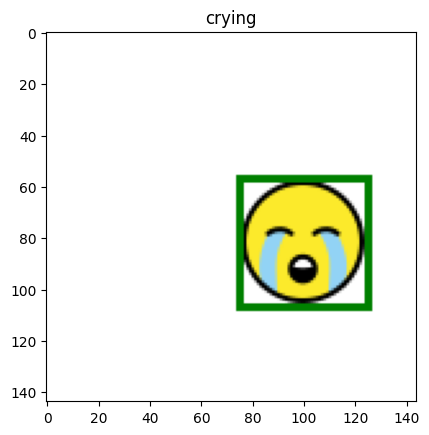

In [9]:
image = plot_bounding_box(image, gt_coords=[row, col])

plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()


In [10]:
def data_generator(batch_size = 16):
  while True:
    x_batch = np.zeros((batch_size, 144, 144, 3))
    y_batch = np.zeros((batch_size, 9))
    bbox_batch = np.zeros((batch_size, 2))


    for i in range(0, batch_size):
      image, class_id, row, col = create_example()
      x_batch[i] = image / 255
      y_batch[i, class_id] = 1.0
      bbox_batch[i] = np.array([row, col])

    yield {'image' : x_batch}, {'class_out':y_batch, 'box_out' : bbox_batch}


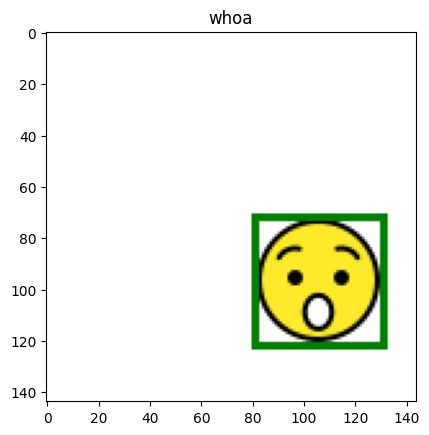

In [11]:
example, label = next(data_generator(1))
image = example['image'][0]
class_id = np.argmax(label['class_out'])
coords = label['box_out'][0]

image = plot_bounding_box(image, coords, norm = True)
plt.imshow(image)
plt.title(emojis[class_id]['name'])
plt.show()


In [13]:
inputs = tf.keras.Input(shape=(144, 144, 3), name='image')

x = inputs

for i in range(5):
    n_filters = 2 ** (4 + i)
    x = tf.keras.layers.Conv2D(n_filters, 3, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)

class_out = tf.keras.layers.Dense(9, activation='softmax', name='class_out')(x)
box_out   = tf.keras.layers.Dense(2, name='box_out')(x)

model = tf.keras.models.Model(inputs=inputs, outputs=[class_out, box_out])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 144, 144,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 142, 142,  │        448 │ image[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 142, 142,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 71, 71,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 69, 69,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 69,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 34, 34,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 7, 7, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 5, 5, 256) │    295,168 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 5, 5, 256) │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 2, 2, 256) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1024)      │          0 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 659,819 (2.52 MB)

 Trainable params: 658,827 (2.51 MB)

 Non-trainable params: 992 (3.88 KB)

In [14]:
# class IoU(tf.keras.metrics.Metric):
#   def __init__(self, **kwargs):
#     super(IoU, self).__init__(**kwargs)

#     self.iou = self.add_weight(name = 'iou', initializer = 'zeros')
#     self.total_iou = self.add_weight(name = 'total_iou', initializer = 'zeros')
#     self.num_ex = self.add_weight(name = 'num_ex', initializer='zeros')

#   def update_state(self, y_true, y_pred, sample_weight = None):
#     def get_box(y):
#       rows, cols = y[:, 0], y[:, 1]
#       rows, cols = rows * 144, cols * 144
#       y1, y2 = rows, rows + 52
#       x1, x2 = cols,  cols + 52
#       return x1, y1, x2, y2

#     def get_area(x1, y1, x2, y2):
#       return tf.math.abs(x2 - x1) * tf.math.abs(y2 - y1)

#     gt_x1, gt_y1, gt_x2, gt_y2 = get_box(y_true)
#     p_x1, p_y1, p_x2, p_y2 = get_box(y_pred)

#     i_x1 = tf.maximum(gt_x1, p_x1)
#     i_y1 = tf.maximum(gt_y1, p_y1)
#     i_x2 = tf.maximum(gt_x2, p_x2)
#     i_y2 = tf.maximum(gt_y2, p_y2)

#     i_area = get_area(i_x1, i_y1, i_x2, i_y2)
#     u_area = get_area(gt_x1,gt_y1,gt_x2,gt_y2) + get_area(p_x1,p_y1,p_x2,p_y2) - i_area

#     iou = tf.math.divide(i_area, u_area)
#     self.num_ex.assign_add(1)
#     self.total_iou.assign_add(tf.reduce_mean(iou))
#     self.iou = tf.math.divide(self.total_iou, self.num_ex)

#   def result(self):
#    return self.IoU

#   def reset_state(self):
#     self.iou = self.add_weight(name = 'iou', initializer = 'zeros')
#     self.total_iou = self.add_weight(name = 'total_iou', initializer = 'zeros')
#     self.num_ex = self.add_weight(name = 'num_ex', initializer='zeros')



class IoU(tf.keras.metrics.Metric):
    def __init__(self, name='iou', **kwargs):
        super().__init__(name=name, **kwargs)

        self.total_iou = self.add_weight(name='total_iou', initializer='zeros')
        self.num_ex = self.add_weight(name='num_ex', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):

        def get_box(y):
          y = tf.cast(y, tf.float32)

          rows = y[:, 0] * tf.constant(144.0, dtype=tf.float32)
          cols = y[:, 1] * tf.constant(144.0, dtype=tf.float32)

          y1 = rows
          y2 = rows + tf.constant(52.0, dtype=tf.float32)
          x1 = cols
          x2 = cols + tf.constant(52.0, dtype=tf.float32)

          return x1, y1, x2, y2


        def get_area(x1, y1, x2, y2):
            return tf.maximum(0.0, x2 - x1) * tf.maximum(0.0, y2 - y1)

        gt_x1, gt_y1, gt_x2, gt_y2 = get_box(y_true)
        p_x1, p_y1, p_x2, p_y2 = get_box(y_pred)

        i_x1 = tf.maximum(gt_x1, p_x1)
        i_y1 = tf.maximum(gt_y1, p_y1)
        i_x2 = tf.minimum(gt_x2, p_x2)
        i_y2 = tf.minimum(gt_y2, p_y2)

        i_area = get_area(i_x1, i_y1, i_x2, i_y2)
        u_area = (
            get_area(gt_x1, gt_y1, gt_x2, gt_y2)
            + get_area(p_x1, p_y1, p_x2, p_y2)
            - i_area
        )

        iou = i_area / (u_area + 1e-7)

        self.total_iou.assign_add(tf.reduce_mean(iou))
        self.num_ex.assign_add(1.0)

    def result(self):
        return self.total_iou / (self.num_ex + 1e-7)

    def reset_state(self):
        self.total_iou.assign(0.0)
        self.num_ex.assign(0.0)


In [15]:
model.compile(
    loss = {
        'class_out': 'categorical_crossentropy',
        'box_out': 'mse'
    },
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    metrics = {
        'class_out': 'accuracy',
        'box_out':IoU(name = 'iou')
    }
)

In [16]:
def test_model(model, test_datagen):
  example, label = next(test_datagen)
  x = example['image']
  y = label['class_out']
  box = label['box_out']

  pred_y, pred_box = model.predict(x)

  pred_coords = pred_box[0]
  gt_coords = box[0]
  pred_class = np.argmax(pred_y[0])
  image = x[0]

  gt = emojis[np.argmax(y[0])]['name']
  pred_class_name = emojis[pred_class]['name']

  image = plot_bounding_box(image, gt_coords, pred_coords, norm=True)
  color = 'green' if gt == pred_class_name else 'red'

  plt.imshow(image)
  plt.xlabel(f'Pred: {pred_class_name}', color=color)
  plt.ylabel(f'GT: (gt)', color=color)
  plt.xticks([])
  plt.yticks([])

In [17]:
def test(model):
  test_datagen = data_generator(1)

  plt.figure(figsize = (10, 4))

  for i in range(6):
    plt.subplot(1, 6, i+1)
    test_model(model, test_datagen)

  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


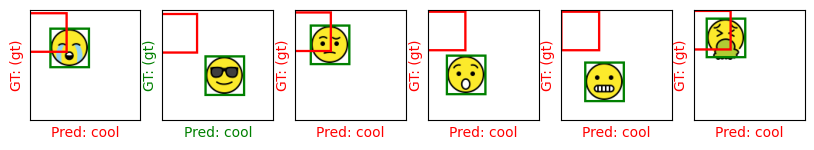

In [18]:
test(model)

In [19]:
class ShowTestImages(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs = None):
    test(self.model)

In [20]:
gen = data_generator()
x, y = next(gen)

print(type(x), x.keys())
print(type(y), y.keys())


<class 'dict'> dict_keys(['image'])
<class 'dict'> dict_keys(['class_out', 'box_out'])


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: image
Received: inputs=['Tensor(shape=(None, 144, 144, 3))']
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


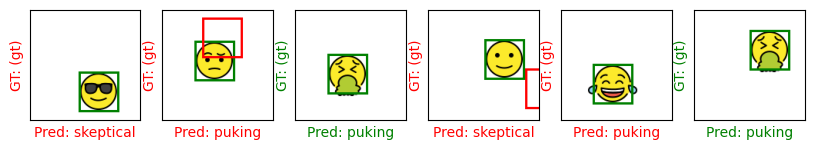

500/500 ━━━━━━━━━━━━━━━━━━━━ 188s 367ms/step - box_out_iou: 0.1160 - box_out_loss: 1.3095 - class_out_accuracy: 0.4854 - class_out_loss: 1.4709 - loss: 2.7803 - learning_rate: 0.0010
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


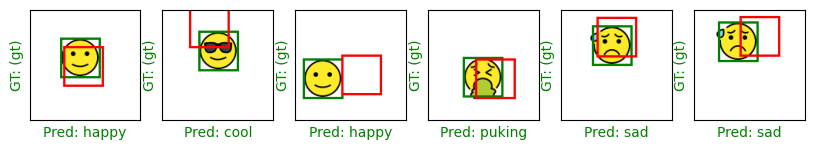

500/500 ━━━━━━━━━━━━━━━━━━━━ 180s 360ms/step - box_out_iou: 0.2405 - box_out_loss: 0.0416 - class_out_accuracy: 0.9976 - class_out_loss: 0.0243 - loss: 0.0659 - learning_rate: 0.0010
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


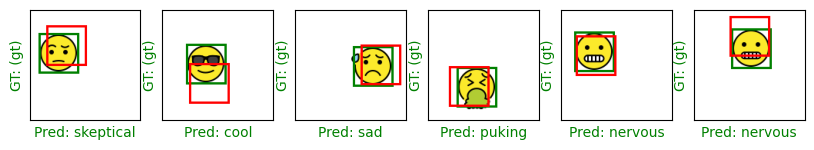

500/500 ━━━━━━━━━━━━━━━━━━━━ 180s 360ms/step - box_out_iou: 0.3790 - box_out_loss: 0.0181 - class_out_accuracy: 0.9988 - class_out_loss: 0.0081 - loss: 0.0262 - learning_rate: 0.0010
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


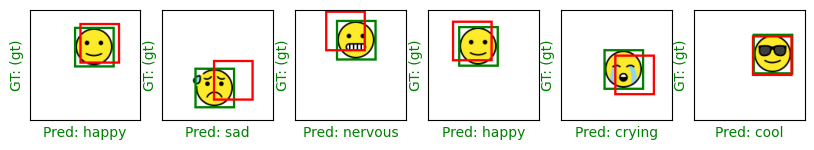

500/500 ━━━━━━━━━━━━━━━━━━━━ 179s 358ms/step - box_out_iou: 0.4794 - box_out_loss: 0.0099 - class_out_accuracy: 1.0000 - class_out_loss: 0.0020 - loss: 0.0119 - learning_rate: 0.0010
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


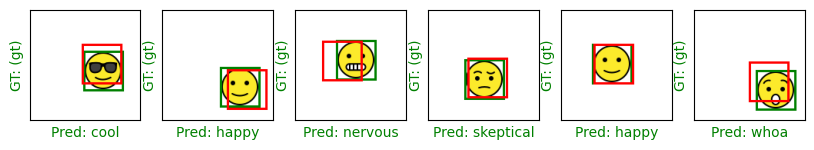

500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 355ms/step - box_out_iou: 0.6162 - box_out_loss: 0.0040 - class_out_accuracy: 1.0000 - class_out_loss: 0.0012 - loss: 0.0052 - learning_rate: 2.0000e-04
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


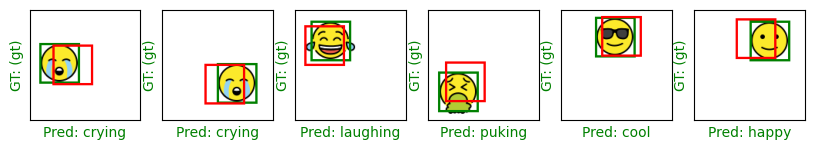

500/500 ━━━━━━━━━━━━━━━━━━━━ 184s 369ms/step - box_out_iou: 0.6517 - box_out_loss: 0.0030 - class_out_accuracy: 1.0000 - class_out_loss: 0.0010 - loss: 0.0040 - learning_rate: 2.0000e-04
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


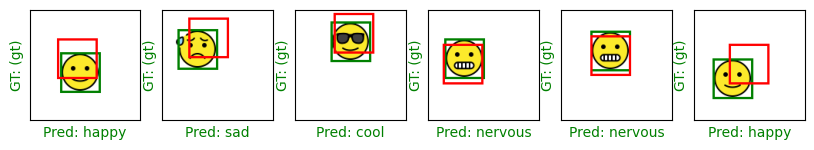

500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 362ms/step - box_out_iou: 0.6634 - box_out_loss: 0.0028 - class_out_accuracy: 1.0000 - class_out_loss: 8.5885e-04 - loss: 0.0036 - learning_rate: 2.0000e-04
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


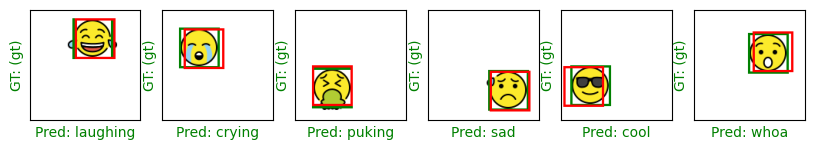

500/500 ━━━━━━━━━━━━━━━━━━━━ 180s 361ms/step - box_out_iou: 0.6697 - box_out_loss: 0.0026 - class_out_accuracy: 1.0000 - class_out_loss: 5.7720e-04 - loss: 0.0032 - learning_rate: 2.0000e-04
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


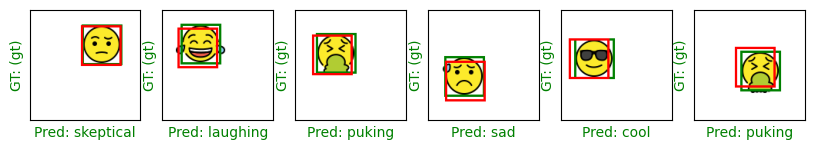

500/500 ━━━━━━━━━━━━━━━━━━━━ 177s 354ms/step - box_out_iou: 0.6813 - box_out_loss: 0.0024 - class_out_accuracy: 1.0000 - class_out_loss: 5.7788e-04 - loss: 0.0029 - learning_rate: 2.0000e-04
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


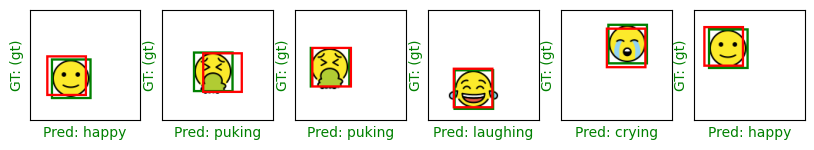

500/500 ━━━━━━━━━━━━━━━━━━━━ 176s 352ms/step - box_out_iou: 0.7176 - box_out_loss: 0.0018 - class_out_accuracy: 1.0000 - class_out_loss: 5.3965e-04 - loss: 0.0023 - learning_rate: 4.0000e-05
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


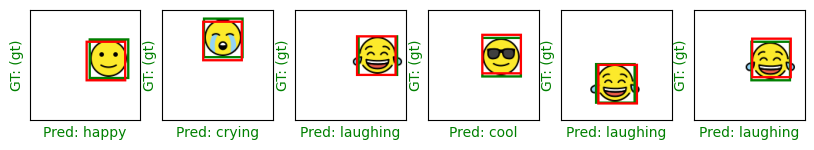

500/500 ━━━━━━━━━━━━━━━━━━━━ 176s 351ms/step - box_out_iou: 0.7250 - box_out_loss: 0.0016 - class_out_accuracy: 1.0000 - class_out_loss: 5.0755e-04 - loss: 0.0021 - learning_rate: 4.0000e-05
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


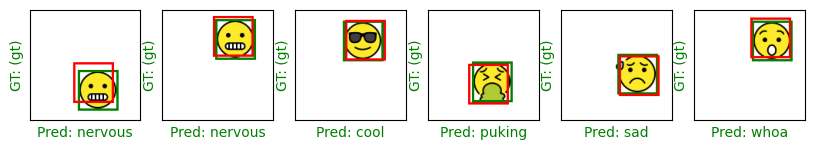

500/500 ━━━━━━━━━━━━━━━━━━━━ 176s 353ms/step - box_out_iou: 0.7269 - box_out_loss: 0.0016 - class_out_accuracy: 1.0000 - class_out_loss: 3.9442e-04 - loss: 0.0020 - learning_rate: 4.0000e-05
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


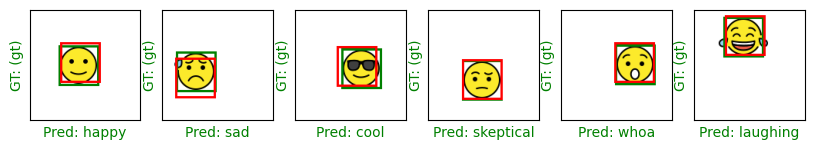

500/500 ━━━━━━━━━━━━━━━━━━━━ 177s 353ms/step - box_out_iou: 0.7347 - box_out_loss: 0.0015 - class_out_accuracy: 1.0000 - class_out_loss: 3.8932e-04 - loss: 0.0019 - learning_rate: 4.0000e-05
Epoch 14/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


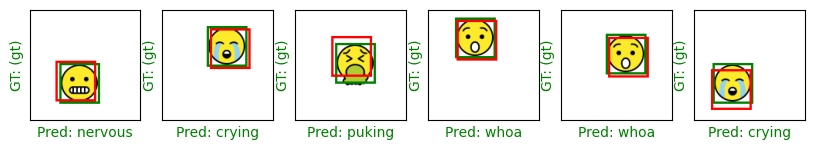

500/500 ━━━━━━━━━━━━━━━━━━━━ 177s 354ms/step - box_out_iou: 0.7339 - box_out_loss: 0.0015 - class_out_accuracy: 1.0000 - class_out_loss: 3.5355e-04 - loss: 0.0019 - learning_rate: 4.0000e-05
Epoch 15/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


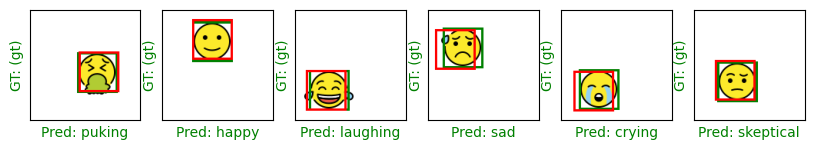

500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 356ms/step - box_out_iou: 0.7498 - box_out_loss: 0.0013 - class_out_accuracy: 1.0000 - class_out_loss: 3.1201e-04 - loss: 0.0016 - learning_rate: 8.0000e-06
Epoch 16/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


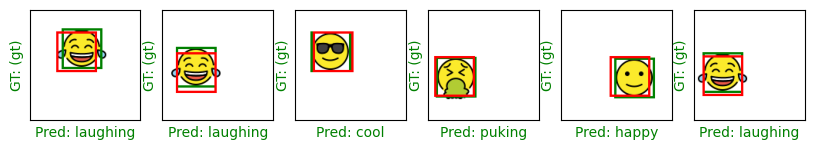

500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 356ms/step - box_out_iou: 0.7535 - box_out_loss: 0.0012 - class_out_accuracy: 1.0000 - class_out_loss: 3.4640e-04 - loss: 0.0016 - learning_rate: 8.0000e-06
Epoch 17/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


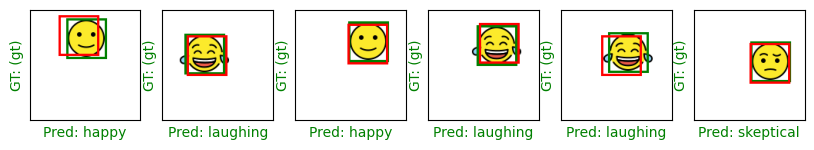

500/500 ━━━━━━━━━━━━━━━━━━━━ 179s 358ms/step - box_out_iou: 0.7584 - box_out_loss: 0.0012 - class_out_accuracy: 1.0000 - class_out_loss: 3.0177e-04 - loss: 0.0015 - learning_rate: 8.0000e-06
Epoch 18/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


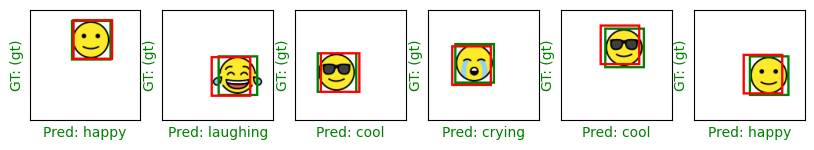

500/500 ━━━━━━━━━━━━━━━━━━━━ 178s 355ms/step - box_out_iou: 0.7615 - box_out_loss: 0.0012 - class_out_accuracy: 1.0000 - class_out_loss: 2.9529e-04 - loss: 0.0014 - learning_rate: 8.0000e-06
Epoch 19/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


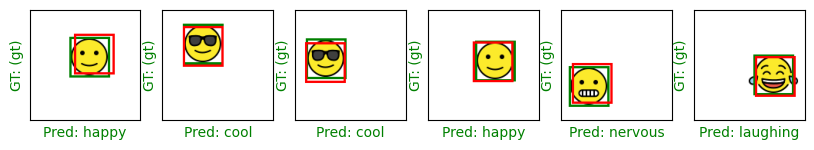

500/500 ━━━━━━━━━━━━━━━━━━━━ 180s 360ms/step - box_out_iou: 0.7633 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 2.6911e-04 - loss: 0.0014 - learning_rate: 8.0000e-06
Epoch 20/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


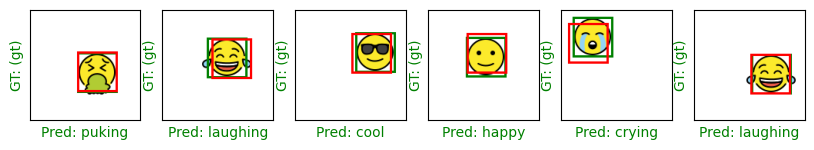

500/500 ━━━━━━━━━━━━━━━━━━━━ 180s 360ms/step - box_out_iou: 0.7627 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 3.0720e-04 - loss: 0.0014 - learning_rate: 1.6000e-06
Epoch 21/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


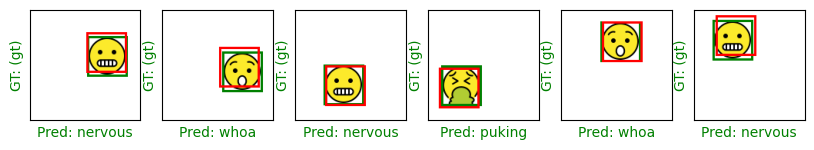

500/500 ━━━━━━━━━━━━━━━━━━━━ 182s 365ms/step - box_out_iou: 0.7645 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 2.9830e-04 - loss: 0.0014 - learning_rate: 1.6000e-06
Epoch 22/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


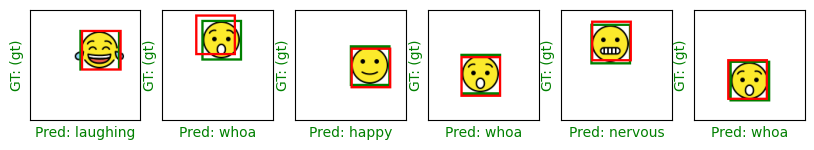

500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 362ms/step - box_out_iou: 0.7688 - box_out_loss: 0.0010 - class_out_accuracy: 1.0000 - class_out_loss: 2.7053e-04 - loss: 0.0013 - learning_rate: 1.6000e-06
Epoch 23/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


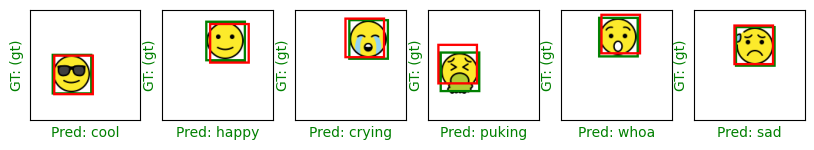

500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 361ms/step - box_out_iou: 0.7682 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 3.0175e-04 - loss: 0.0014 - learning_rate: 1.6000e-06
Epoch 24/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


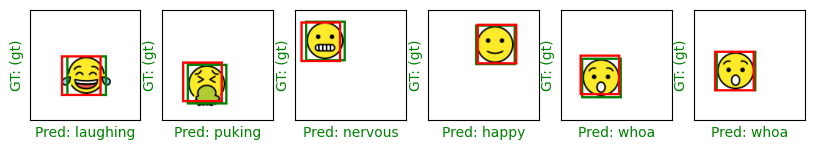

500/500 ━━━━━━━━━━━━━━━━━━━━ 179s 359ms/step - box_out_iou: 0.7669 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 3.4294e-04 - loss: 0.0014 - learning_rate: 1.6000e-06
Epoch 25/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


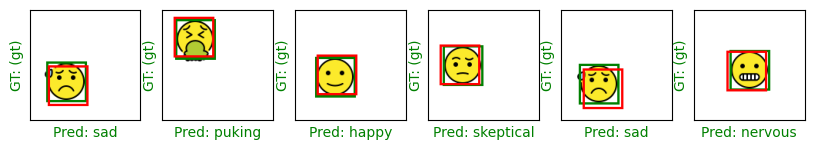

500/500 ━━━━━━━━━━━━━━━━━━━━ 182s 363ms/step - box_out_iou: 0.7692 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 2.4301e-04 - loss: 0.0013 - learning_rate: 3.2000e-07
Epoch 26/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


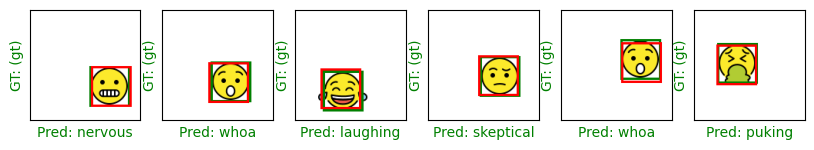

500/500 ━━━━━━━━━━━━━━━━━━━━ 183s 365ms/step - box_out_iou: 0.7695 - box_out_loss: 0.0010 - class_out_accuracy: 1.0000 - class_out_loss: 3.0935e-04 - loss: 0.0014 - learning_rate: 3.2000e-07
Epoch 27/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


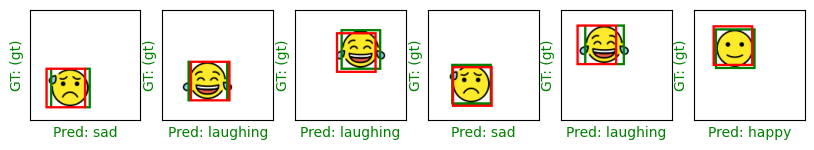

500/500 ━━━━━━━━━━━━━━━━━━━━ 185s 371ms/step - box_out_iou: 0.7687 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 3.3210e-04 - loss: 0.0014 - learning_rate: 3.2000e-07
Epoch 28/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


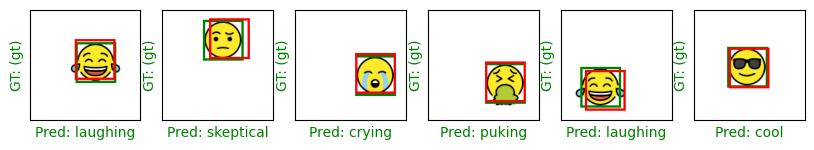

500/500 ━━━━━━━━━━━━━━━━━━━━ 186s 371ms/step - box_out_iou: 0.7683 - box_out_loss: 0.0011 - class_out_accuracy: 1.0000 - class_out_loss: 2.6373e-04 - loss: 0.0013 - learning_rate: 3.2000e-07


In [21]:
def lr_schedule(epoch, lr):
  if (epoch + 1) % 5 == 0:
    lr *= 0.2
  return max(lr, 3e-7)

model.fit(
    data_generator(),
    epochs = 50,
    steps_per_epoch = 500,
    callbacks = [
        ShowTestImages(),
        tf.keras.callbacks.EarlyStopping(monitor='box_out_iou', patience = 3, mode = 'max'),
        tf.keras.callbacks.LearningRateScheduler(lr_schedule)
    ]
)


In [ ]:
iou = IoU()
print(iou(tf.random.uniform((4,2)), tf.random.uniform((4,2))))


In [ ]:
print("Input names:", model.input_names)
print("Output names:", model.output_names)
print("Loss keys:", model.loss)
